# 07 · El gym · ponerle lentes a Qwen (SFT + LoRA)

**Parte III · El oficio.** En el notebook 05 viste que Qwen con notas toma bien los hechos y falla el **oficio**: no da 5 bullets, no cita el medio entre paréntesis, no rellena con "no aparece". En el 06 armaste filas limpias. Aquí entrenas los lentes con esas filas y los pruebas.

Pensado para **Colab con GPU T4** (Entorno de ejecución → Cambiar tipo → T4). También corre en una Mac con Apple Silicon (MPS) o en CPU, más lento. Con las 44 filas de ejemplo y 8 épocas: ~1–2 min en T4 o MPS.

Lo que te llevas:

1. Cuántos parámetros entrena LoRA de verdad (no "pocos": el número).
2. La curva de pérdida y qué significa que val baje o suba.
3. El mismo prompt con lentes y sin lentes, calificado por el juez.
4. Un adapter de ~4 MB que es tu entregable del reto.

## Dummy (antes de la fórmula)

Qwen ya sabe español y ya sabe leer notas. Reentrenarlo completo sería como mandar a un chef a la escuela de cocina otra vez para que aprenda a emplatar: carísimo y se le olvidan recetas. LoRA le pone **lentes**: dos matrices delgadas que se suman a algunas de sus matrices, y solo esas se entrenan. Le quitas los lentes y vuelve a ser el Qwen de Hugging Face, intacto.

El entrenamiento es el mismo juego del notebook 01 (adivina el siguiente token), pero el modelo **solo paga** por equivocarse en el briefing. Las notas son contexto.

## Matemática (la misma idea, en serio)

Para cada matriz congelada $W\in\mathbb{R}^{d\times k}$ elegida (aquí `q_proj` y `v_proj` de la atención):

$$
W' = W + \frac{\alpha}{r}\,BA,\qquad B\in\mathbb{R}^{d\times r},\ A\in\mathbb{R}^{r\times k},\ r\ll\min(d,k).
$$

$B$ arranca en ceros, así que al inicio $W'=W$: el entrenamiento parte del Qwen original. Se entrenan $r(d+k)$ números por matriz en vez de $dk$.

La pérdida es la entropía cruzada con máscara $m_t=1$ solo en tokens del assistant:

$$
\mathcal{L}_{\mathrm{SFT}}(\theta_{A,B}) = -\frac{1}{\sum_t m_t}\sum_t m_t\log P_{W+\frac{\alpha}{r}BA}(x_t\mid x_{<t}).
$$

`sft_lora_noticias.py` parte cada fila en `prompt` (system + user) y `completion` (assistant); en ese formato TRL pone $m_t=0$ en el prompt.

## 0 · Instalar y configurar

In [1]:
# Colab: descomenta (una vez).
# %pip install -q "transformers>=4.45" "trl>=0.20" peft datasets accelerate
# %pip install -q bitsandbytes            # solo si vas a usar QLORA = True (GPU NVIDIA)
# !wget -q https://raw.githubusercontent.com/NoSoyRo/diplomado-ia-llms/main/parte-3-oficio/sft_lora_noticias.py
# !wget -q https://raw.githubusercontent.com/NoSoyRo/diplomado-ia-llms/main/parte-3-oficio/don_titular.py
# !wget -q https://raw.githubusercontent.com/NoSoyRo/diplomado-ia-llms/main/parte-3-oficio/ejemplo-briefing.jsonl
# !wget -q https://raw.githubusercontent.com/NoSoyRo/diplomado-ia-llms/main/parte-3-oficio/holdout.jsonl

import json
import subprocess
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

OFICIO = next((p for p in (Path("."), Path("../parte-3-oficio")) if (p / "sft_lora_noticias.py").exists()), Path("."))
sys.path.insert(0, str(OFICIO.resolve()))
import don_titular as dt
import torch

if torch.cuda.is_available():
    DISPOSITIVO = "cuda"
elif torch.backends.mps.is_available():
    DISPOSITIVO = "mps"
else:
    DISPOSITIVO = "cpu"

CONFIG = {
    "model": "Qwen/Qwen2.5-0.5B-Instruct",
    "data": "ejemplo-briefing.jsonl",   # cámbialo por tu mi-dataset.jsonl
    "out": "don-titular-lora",
    "epochs": 8,      # 44 filas son pocas: más pasadas. Con 200+ filas, 2–3 bastan.
    "lr": 2e-4,
    "r": 16,
    "bs": 2,
    "accum": 4,       # batch efectivo = bs × accum = 8
    "seed": 42,
}
QLORA = False  # True en Colab T4 si usas un modelo de 1–2 B; con 0.5 B no hace falta

print(f"dispositivo={DISPOSITIVO} · {CONFIG}")

dispositivo=mps · {'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'data': 'ejemplo-briefing.jsonl', 'out': 'don-titular-lora', 'epochs': 8, 'lr': 0.0002, 'r': 16, 'bs': 2, 'accum': 4, 'seed': 42}


## 1 · Antes de gastar GPU: la regla de oro

Si una sola fila inventa, se entrena con ella. El gym **no arranca** si el juez tira alguna fila.

In [2]:
total, tirados = dt.validar_jsonl(OFICIO / CONFIG["data"])
print(f"{total - len(tirados)}/{total} filas pasan la regla de oro")
for renglon, problemas in tirados[:5]:
    print(f"  renglón {renglon}: {problemas}")
assert not tirados, "Limpia el dataset (notebook 06) antes de entrenar."

44/44 filas pasan la regla de oro


## 2 · ¿Cuántos parámetros entrenan los lentes?

Cargamos Qwen, le ponemos la misma configuración LoRA que usa el script y contamos.

In [3]:
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging

logging.set_verbosity_error()

tok = AutoTokenizer.from_pretrained(CONFIG["model"])
base = AutoModelForCausalLM.from_pretrained(CONFIG["model"])
total_base = sum(p.numel() for p in base.parameters())
capa = base.model.layers[0].self_attn
print(f"q_proj: {tuple(capa.q_proj.weight.shape)} · v_proj: {tuple(capa.v_proj.weight.shape)} · capas: {len(base.model.layers)}")

conteo = get_peft_model(
    base, LoraConfig(r=CONFIG["r"], lora_alpha=2 * CONFIG["r"], target_modules=["q_proj", "v_proj"], task_type="CAUSAL_LM")
)
entrenables = sum(p.numel() for p in conteo.parameters() if p.requires_grad)
print(f"entrenables: {entrenables:,} de {total_base:,} ({entrenables / total_base:.2%})")
del conteo, base

q_proj: (896, 896) · v_proj: (128, 896) · capas: 24
entrenables: 1,081,344 de 494,032,768 (0.22%)


Compáralo con la cuenta a mano de [`notas/03_el_oficio.md`](../notas/03_el_oficio.md): $16\cdot(896+896) + 16\cdot(128+896) = 45\,056$ por capa, × 24 capas = 1 081 344. `v_proj` es más chica (128 × 896) porque Qwen usa *grouped-query attention*: 14 cabezas de query comparten 2 cabezas de key/value.

## 3 · Entrenar

Llamamos al **mismo** script que corres desde la terminal: una sola fuente de verdad. Imprime la pérdida cada 5 pasos y la de validación al final de cada época.

In [4]:
cmd = [sys.executable, "sft_lora_noticias.py"]
for k in ("model", "data", "out", "epochs", "lr", "r", "bs", "accum", "seed"):
    cmd += [f"--{k}", str(CONFIG[k])]
if QLORA:
    cmd.append("--4bit")

proc = subprocess.run(cmd, cwd=OFICIO, capture_output=True, text=True)
lineas = [r for r in proc.stdout.splitlines() if any(k in r for k in ("loss", "Adapter", "batch", "Aviso"))]
print("\n".join(lineas[-12:]) or proc.stdout[-2000:])
if proc.returncode != 0:
    print(proc.stderr[-3000:])
    raise RuntimeError("el gym falló; lee el error de arriba")

{'loss': '0.5999', 'grad_norm': '1.423', 'learning_rate': '0.000105', 'entropy': '0.7195', 'num_tokens': '3.438e+04', 'mean_token_accuracy': '0.8687', 'epoch': '4'}
{'eval_loss': '0.6217', 'eval_runtime': '0.2062', 'eval_samples_per_second': '24.25', 'eval_steps_per_second': '14.55', 'eval_entropy': '0.6928', 'eval_num_tokens': '3.438e+04', 'eval_mean_token_accuracy': '0.8557', 'epoch': '4'}
{'loss': '0.527', 'grad_norm': '1.677', 'learning_rate': '8e-05', 'entropy': '0.5891', 'num_tokens': '4.298e+04', 'mean_token_accuracy': '0.8824', 'epoch': '5'}
{'eval_loss': '0.584', 'eval_runtime': '0.2052', 'eval_samples_per_second': '24.37', 'eval_steps_per_second': '14.62', 'eval_entropy': '0.6069', 'eval_num_tokens': '4.298e+04', 'eval_mean_token_accuracy': '0.8494', 'epoch': '5'}
{'loss': '0.4774', 'grad_norm': '1.787', 'learning_rate': '5.5e-05', 'entropy': '0.5229', 'num_tokens': '5.157e+04', 'mean_token_accuracy': '0.8959', 'epoch': '6'}
{'eval_loss': '0.5579', 'eval_runtime': '0.2042', '

### La curva

 época   train     val
     1   1.096   0.936
     2   0.853   0.791
     3   0.706   0.693
     4   0.600   0.622
     5   0.527   0.584
     6   0.477   0.558
     7   0.436   0.547
     8   0.421   0.543


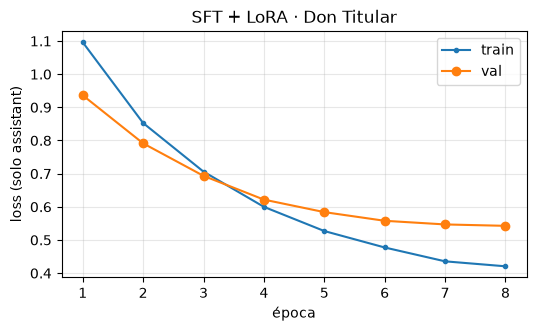

In [5]:
OUT = OFICIO / CONFIG["out"]
estado = max(OUT.glob("checkpoint-*/trainer_state.json"), key=lambda p: int(p.parent.name.split("-")[1]))
historia = json.loads(estado.read_text())["log_history"]

train = [(h["epoch"], h["loss"]) for h in historia if "loss" in h]
val = [(h["epoch"], h["eval_loss"]) for h in historia if "eval_loss" in h]
ultima_train = {round(e): perdida for e, perdida in train}
print(f"{'época':>6} {'train':>7} {'val':>7}")
for e, perdida in val:
    print(f"{e:>6.0f} {ultima_train.get(round(e), float('nan')):>7.3f} {perdida:>7.3f}")

try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 3.2))
    plt.plot(*zip(*train), label="train", marker=".")
    plt.plot(*zip(*val), label="val", marker="o")
    plt.xlabel("época")
    plt.ylabel("loss (solo assistant)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title("SFT + LoRA · Don Titular")
    plt.show()
except ImportError:
    print("(sin matplotlib: solo tabla)")

**Cómo leerla.** El script aparta 5 de las 44 filas al azar (val) y entrena con 39. Val baja época tras época y se aplana cerca de 0.54: aprendió algo que sirve en filas que no vio. Train la cruza hacia la época 4 y sigue bajando (≈0.42 al final): ese hueco que se abre es el principio de la memorización. Si val empezara a **subir** mientras train baja, para: menos épocas o más datos. Con 5 filas de val la curva es ruidosa; no le leas el tercer decimal.

Para tener una referencia, una loss de ~0.5 equivale a una perplejidad de $e^{0.5}\approx 1.6$ sobre los tokens del briefing: el formato ya casi no le sorprende.

## 4 · Con lentes vs sin lentes

Mismo modelo, mismos pesos $W$. `disable_adapter()` quita los lentes sin recargar nada: si la salida vuelve a ser la del Qwen original, comprobaste que $W$ no se tocó.

Entrenar en GPU (CUDA o MPS) no es reproducible bit a bit aun con semilla fija: tus salidas con lentes pueden diferir un poco de las guardadas en el notebook 08. Lo que debe repetirse es el **patrón** (formato sí, citas a medias), no cada palabra.

In [6]:
from peft import PeftModel

modelo = PeftModel.from_pretrained(AutoModelForCausalLM.from_pretrained(CONFIG["model"]), str(OUT)).to(DISPOSITIVO).eval()


def generar(mensajes, max_new_tokens=200):
    entrada = tok.apply_chat_template(mensajes, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(DISPOSITIVO)
    with torch.no_grad():
        out = modelo.generate(**entrada, max_new_tokens=max_new_tokens, do_sample=False,
                              temperature=None, top_p=None, top_k=None, pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, entrada["input_ids"].shape[1]:], skip_special_tokens=True).strip()


HOLDOUT = [json.loads(r) for r in (OFICIO / "holdout.jsonl").read_text(encoding="utf-8").splitlines()]
for caso in (HOLDOUT[2], HOLDOUT[7]):
    msgs = dt.mensajes(caso["notas"])
    with modelo.disable_adapter():
        sin = generar(msgs)
    con = generar(msgs)
    print(f"══ {caso['id']}\n{caso['notas']}\n")
    print(f"── sin lentes · {dt.juzgar(caso['notas'], sin).resumen()}\n{sin}\n")
    print(f"── con lentes · {dt.juzgar(caso['notas'], con).resumen()}\n{con}\n")

══ h3-deportes
Notas del 2026-08-22:
1. ESPN — Pumas vence 2-0 a Cruz Azul en el Olímpico Universitario.
2. Marca — El Tri convoca a 26 jugadores para la fecha FIFA.
   Regresa un portero tras lesión.
3. Récord — La Liga MX anuncia horario de la jornada 8.

── sin lentes · formato ✘ · citas ✘ · soporte 75% · 4 problema(s)
**Resumen:**
- **ESPN**: Los Pumas derrotan al Cruz Azul en el Olímpico Universitario, logrando su victoria en la fecha 2026 de la Liga MX.
- **Marca**: El Tri convoca a 26 jugadores para la fecha FIFA, incluyendo un portero recuperado tras una lesión.
- **Récords**: La Liga MX anuncia el horario de la jornada 8, con el objetivo de mejorar la participación de los equipos locales en este torneo.

**Medio de publicación:** ESPN y marca.

── con lentes · formato ✔ · citas ✘ · soporte 100% · 1 problema(s)
1) Pumas (ESPN): vence 2-0 a Cruz Azul en el Olímpico Universitario.
2) Porteros (Marca): regresa un portero tras lesión.
3) Liga MX: anuncia horario de la jornada 8.
4)

══ h8-tecnologia
Notas del 2026-08-27:
1. Expansión — Una empresa de chips abre planta en Jalisco con 800 empleos.
2. El Economista — El IFT asigna espectro para redes 5G.
   La subasta recaudó 2 mil millones de pesos.

── sin lentes · formato ✘ · citas ✘ · soporte 67% · 3 problema(s)
Expansión: Un nuevo chip de la empresa de chips abre una planta en Jalisco con 800 empleos.

El Economista: El Instituto Federal de Telecomunicaciones (IFT) asigna un espacio para redes 5G en México.

Subasta: La subasta de redes 5G recaudó 2 mil millones de pesos.

── con lentes · formato ✔ · citas ✘ · soporte 100% · 2 problema(s)
1) Expansión (Expansión): una empresa de chips abre planta en Jalisco con 800 empleos.
2) Subasta (El Economista): la subasta recaudó 2 mil millones de pesos.
3) 5G (IFT): la subasta recaudó 2 mil millones de pesos.
4) Economía: no aparece.
5) Tema: no aparece.



Fíjate en tres cosas:

- **Formato.** Con lentes salen 5 bullets numerados y "no aparece" de relleno, que es lo que ningún prompt logró (notebook 08: zero-shot 0/10, few-shot 1/10).
- **Citas.** Aparece `Tema (Medio):`, pero no en todos los bullets. En los 10 prompts el LoRA de referencia cita bien la mitad, igual que zero-shot: con 44 filas el formato se aprende y el hábito de citar todavía no.
- **Lo que el juez no ve.** Lee los "no aparece": ¿alguno esconde un tema que **sí** estaba en las notas? Esa es la siguiente mentira que tienes que cazar.

La tabla completa (10 prompts × 3 condiciones) está en el notebook 08.

## 5 · El entregable: un adapter de unos MB

In [7]:
for p in sorted(OUT.iterdir()):
    if p.is_file():
        print(f"{p.name:32} {p.stat().st_size / 1e6:8.2f} MB")
print("\nentrenamiento.json:", json.loads((OUT / "entrenamiento.json").read_text()))
print(f"\nQwen completo pesa ~{total_base * 4 / 1e9:.1f} GB en fp32; tus lentes, lo de arriba.")

README.md                            0.00 MB
adapter_config.json                  0.00 MB
adapter_model.safetensors            4.34 MB
chat_template.jinja                  0.00 MB
entrenamiento.json                   0.00 MB
tokenizer.json                      11.42 MB
tokenizer_config.json                0.00 MB
training_args.bin                    0.01 MB

entrenamiento.json: {'model_id': 'Qwen/Qwen2.5-0.5B-Instruct', 'data': 'ejemplo-briefing.jsonl', 'n_filas': 44, 'epochs': 8.0, 'lr': 0.0002, 'seed': 42, 'batch_efectivo': 8, 'qlora_4bit': False}

Qwen completo pesa ~2.0 GB en fp32; tus lentes, lo de arriba.


En Colab, descárgalo antes de que se cierre la sesión:

```python
!zip -qr don-titular-lora.zip don-titular-lora -x "*/checkpoint-*"
from google.colab import files; files.download("don-titular-lora.zip")
```

---

## Entregable (reto)

1. La curva train/val y una frase: ¿memorizó o generalizó?
2. `adapter_config.json` + `entrenamiento.json` (modelo, r, lr, épocas, semilla, filas).
3. Dos salidas con lentes y sin lentes sobre tu hold-out, con el `resumen()` del juez.
4. Corre el notebook 08 con `GENERAR = True` para la tabla completa.

## Para romperlo

- `epochs = 2`. ¿Qué aprende primero, el formato o las citas?
- `r = 4` y `r = 64`. ¿Cambia la val loss? ¿Y el tamaño del adapter?
- Mete al dataset 5 filas con un hecho inventado (sin pasar por `agregar`) y reentrena. ¿Empieza a inventar en el hold-out?
- Agrega `"k_proj", "o_proj"` a `target_modules` en el script. ¿Cuántos parámetros más? ¿Vale la pena?